In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

dataset_path = 'cicids2017_cleaned.csv'
print("Environment setup complete")

Environment setup complete


# Random Forest IDS Model - V2 (Optimized for Real Traffic)

This notebook implements an improved training strategy with:
- **Stratified sampling** (750K from 2.5M records) for safe memory/time
- **Port feature removal** to eliminate domain overfitting
- **Class weight balancing** to handle attack underrepresentation
- **Stratified cross-validation** for robust evaluation
- **Feature importance analysis** with explainability
- **Confidence scores** for actionable alerts

## 1. Load & Stratified Sample Dataset

**Goal:** Load full dataset, then sample 750K records (30%) stratified by Attack Type to preserve class ratios while fitting in RAM.

In [2]:
# Load full dataset
print("Loading full dataset...")
df_full = pd.read_csv(dataset_path)
print(f"Full dataset shape: {df_full.shape}")
print(f"Memory usage: {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Show original class distribution
print("\nOriginal class distribution:")
original_dist = df_full['Attack Type'].value_counts()
print(original_dist)
print("\nOriginal class percentages:")
print(df_full['Attack Type'].value_counts(normalize=True) * 100)

Loading full dataset...
Full dataset shape: (2520751, 53)
Memory usage: 1.20 GB

Original class distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

Original class percentages:
Attack Type
Normal Traffic    83.112414
DoS                7.686003
DDoS               5.078407
Port Scanning      3.597896
Brute Force        0.362987
Web Attacks        0.085014
Bots               0.077279
Name: proportion, dtype: float64


In [3]:
# Stratified sampling (30% = ~750K records)
sample_fraction = 0.30
print(f"\nPerforming stratified sampling: {sample_fraction*100:.0f}% of data")

# Use train_test_split to stratify by Attack Type
# We want 30% for training, 70% to discard
_, df = train_test_split(
    df_full,
    test_size=sample_fraction,  # Keep 30% = ~750K records
    random_state=42,
    stratify=df_full['Attack Type']  # Preserve class ratios
)

print(f"Sampled dataset shape: {df.shape}")
print(f"Memory usage after sampling: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Verify class distribution matches original
print("\nSampled class distribution:")
sampled_dist = df['Attack Type'].value_counts()
print(sampled_dist)

print("\nSampled class percentages:")
sampled_pct = df['Attack Type'].value_counts(normalize=True) * 100
print(sampled_pct)

print("\nDistribution comparison (should be <1% difference):")
original_pct = df_full['Attack Type'].value_counts(normalize=True) * 100
comparison = pd.DataFrame({
    'Original %': original_pct,
    'Sampled %': sampled_pct,
    'Difference': abs(original_pct - sampled_pct)
})
print(comparison)


Performing stratified sampling: 30% of data
Sampled dataset shape: (756226, 53)
Memory usage after sampling: 0.37 GB

Sampled class distribution:
Attack Type
Normal Traffic    628518
DoS                58124
DDoS               38404
Port Scanning      27208
Brute Force         2745
Web Attacks          643
Bots                 584
Name: count, dtype: int64

Sampled class percentages:
Attack Type
Normal Traffic    83.112456
DoS                7.686062
DDoS               5.078376
Port Scanning      3.597866
Brute Force        0.362987
Web Attacks        0.085027
Bots               0.077226
Name: proportion, dtype: float64

Distribution comparison (should be <1% difference):
                Original %  Sampled %    Difference
Attack Type                                        
Normal Traffic   83.112414  83.112456  4.207910e-05
DoS               7.686003   7.686062  5.900326e-05
DDoS              5.078407   5.078376  3.114794e-05
Port Scanning     3.597896   3.597866  2.977751e-05
Brute 

## 2. Analyze Class Distribution

**Goal:** Visualize class imbalance to understand minority/majority attack types.

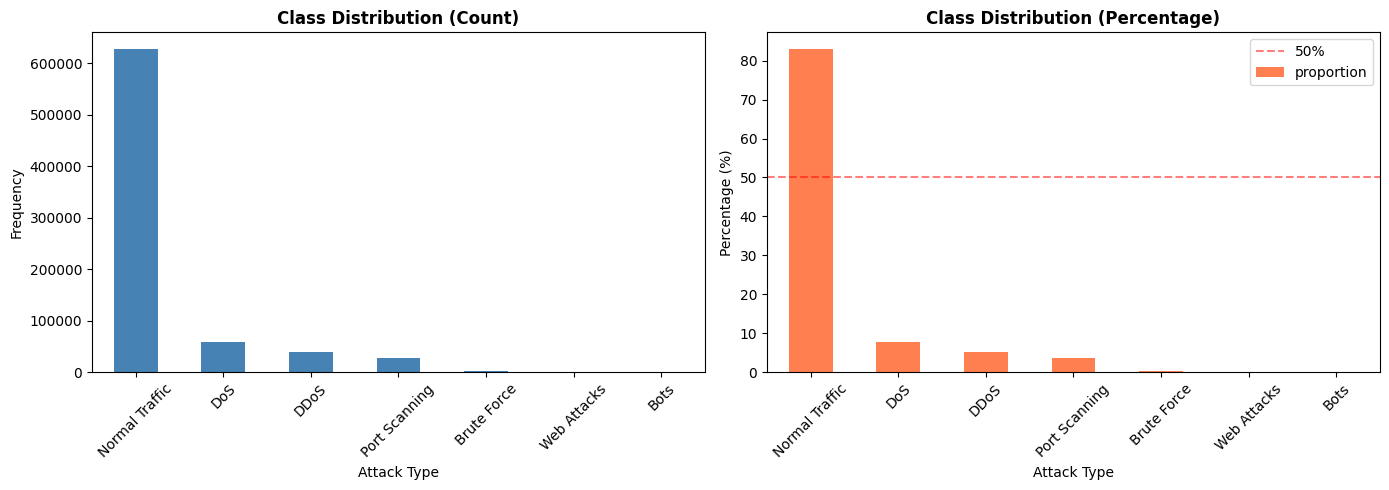


Imbalance ratio (Benign:Attack): 0.00:1


In [4]:
import matplotlib.pyplot as plt

# Class distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Attack Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
(df['Attack Type'].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (Benign:Attack): {(df['Attack Type'] == 'Benign').sum() / (df['Attack Type'] != 'Benign').sum():.2f}:1")

## 3. Feature Engineering - Remove Destination Port Features

**Goal:** Identify and remove destination port (and port-related) features to eliminate domain overfitting.

In [5]:
# Separate features and target
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

print(f"Original feature count: {X.shape[1]}")
print(f"Original features:\n{X.columns.tolist()}")

# Identify port-related features
port_features = [col for col in X.columns if 'port' in col.lower() or 'destination' in col.lower()]
print(f"\nPort-related features to remove ({len(port_features)}):")
for i, feat in enumerate(port_features, 1):
    print(f"  {i}. {feat}")

# Remove port features
X = X.drop(columns=port_features)
print(f"\nFeature count after removal: {X.shape[1]}")
print(f"Features removed: {len(port_features)}")

# Save feature list for later use
features_to_use = X.columns.tolist()
joblib.dump(features_to_use, './model/model_columns_v2.joblib')
print(f"\nFeature list saved to: ./model/model_columns_v2.joblib")

Original feature count: 52
Original features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Ma

## 4. Train-Test Split with Stratification

**Goal:** Split data maintaining class ratios in both train and test sets.

In [6]:
# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensure same class ratio in train/test
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set shape: (604980, 51)
Test set shape: (151246, 51)

Training set class distribution:
Attack Type
Normal Traffic    502814
DoS                46499
DDoS               30723
Port Scanning      21766
Brute Force         2196
Web Attacks          515
Bots                 467
Name: count, dtype: int64

Test set class distribution:
Attack Type
Normal Traffic    125704
DoS                11625
DDoS                7681
Port Scanning       5442
Brute Force          549
Web Attacks          128
Bots                 117
Name: count, dtype: int64


## 5. Train Random Forest with Class Weights

**Goal:** Train RF with balanced class weights to penalize misclassification of minority attack classes.

In [7]:
print("Training Random Forest with class_weight='balanced'...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # KEY: Weight classes inversely to their frequencies
    max_depth=None,  # Will optimize in next section
    n_jobs=-1  # Use all cores
)

rf_model.fit(X_train, y_train)
print("Model training complete!")

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)  # Get probability estimates

print(f"\nTraining set accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test set accuracy: {accuracy_score(y_test, y_pred):.4f}")

Training Random Forest with class_weight='balanced'...
Model training complete!

Training set accuracy: 0.9996
Test set accuracy: 0.9984


## 6. Stratified Cross-Validation

**Goal:** Evaluate model robustness using stratified k-fold cross-validation.

In [8]:
# Stratified k-fold cross-validation (5 folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing 5-fold stratified cross-validation...")
rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Cross-validation scores
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=skf, scoring='f1_weighted')

print(f"\nCross-validation F1 scores (weighted):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Performing 5-fold stratified cross-validation...

Cross-validation F1 scores (weighted):
  Fold 1: 0.9983
  Fold 2: 0.9982
  Fold 3: 0.9983
  Fold 4: 0.9985
  Fold 5: 0.9984

Mean F1 score: 0.9983 (+/- 0.0001)


## 7. Per-Class Performance Analysis

**Goal:** Detailed precision/recall/F1 for each attack type.

Classification Report:
                precision    recall  f1-score   support

          Bots     0.8119    0.7009    0.7523       117
   Brute Force     0.9981    0.9727    0.9852       549
          DDoS     0.9997    0.9995    0.9996      7681
           DoS     0.9966    0.9949    0.9957     11625
Normal Traffic     0.9990    0.9991    0.9990    125704
 Port Scanning     0.9894    0.9987    0.9941      5442
   Web Attacks     0.9916    0.9219    0.9555       128

      accuracy                         0.9984    151246
     macro avg     0.9695    0.9411    0.9545    151246
  weighted avg     0.9984    0.9984    0.9984    151246



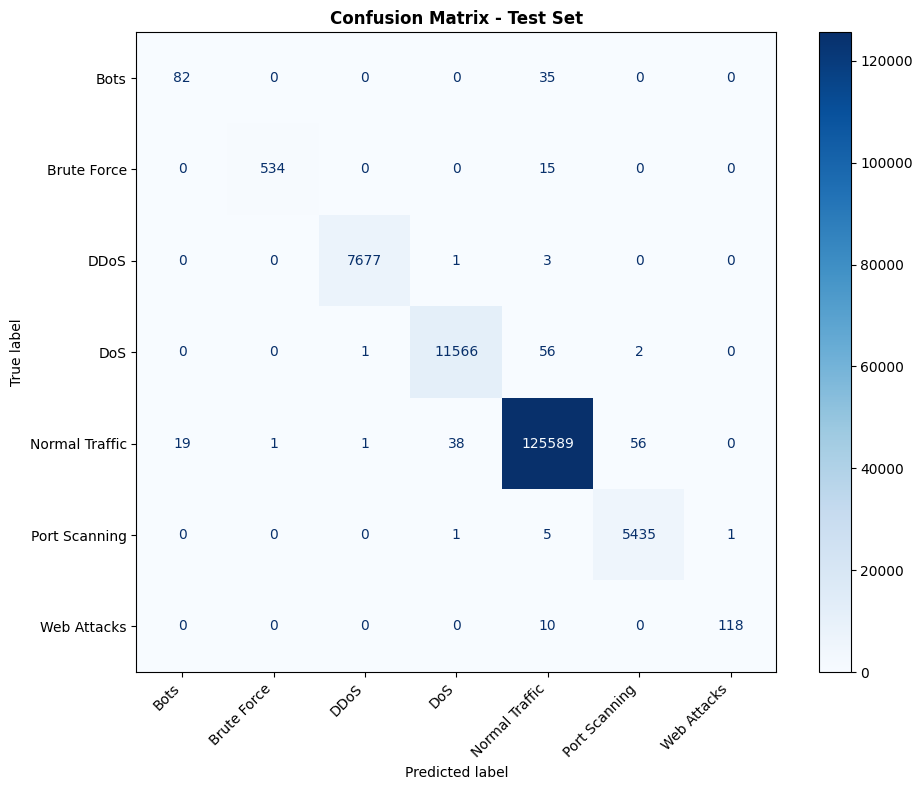

Normal Traffic: Recall=0.9991
DoS: Recall=0.9949
DDoS: Recall=0.9995
Brute Force: Recall=0.9727
Port Scanning: Recall=0.9987
Web Attacks: Recall=0.9219
Bots: Recall=0.7009


In [9]:
print("Classification Report:")
print("="*80)
print(classification_report(y_test, y_pred, digits=4))
print("="*80)

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class F1 scores
from sklearn.metrics import f1_score
for attack_type in y_test.unique():
    mask = y_test == attack_type
    if mask.sum() > 0:
        f1 = f1_score(y_test[mask], y_pred[mask], average='weighted', zero_division=0)
        recall = (y_pred[mask] == attack_type).sum() / mask.sum()
        print(f"{attack_type}: Recall={recall:.4f}")

## 8. Feature Importance Analysis

**Goal:** Identify top 10 features; verify destination port is NOT dominant.

Top 10 Most Important Features:
Init_Win_bytes_backward                  0.074151
Total Length of Fwd Packets              0.046820
Bwd Header Length                        0.045340
Average Packet Size                      0.044408
Packet Length Mean                       0.043794
Bwd Packet Length Mean                   0.042743
Subflow Fwd Bytes                        0.038295
Fwd Packet Length Mean                   0.037860
Fwd Packet Length Max                    0.036984
Bwd Packet Length Max                    0.030469

✓ SUCCESS: No port features in top 10 (overfitting eliminated)


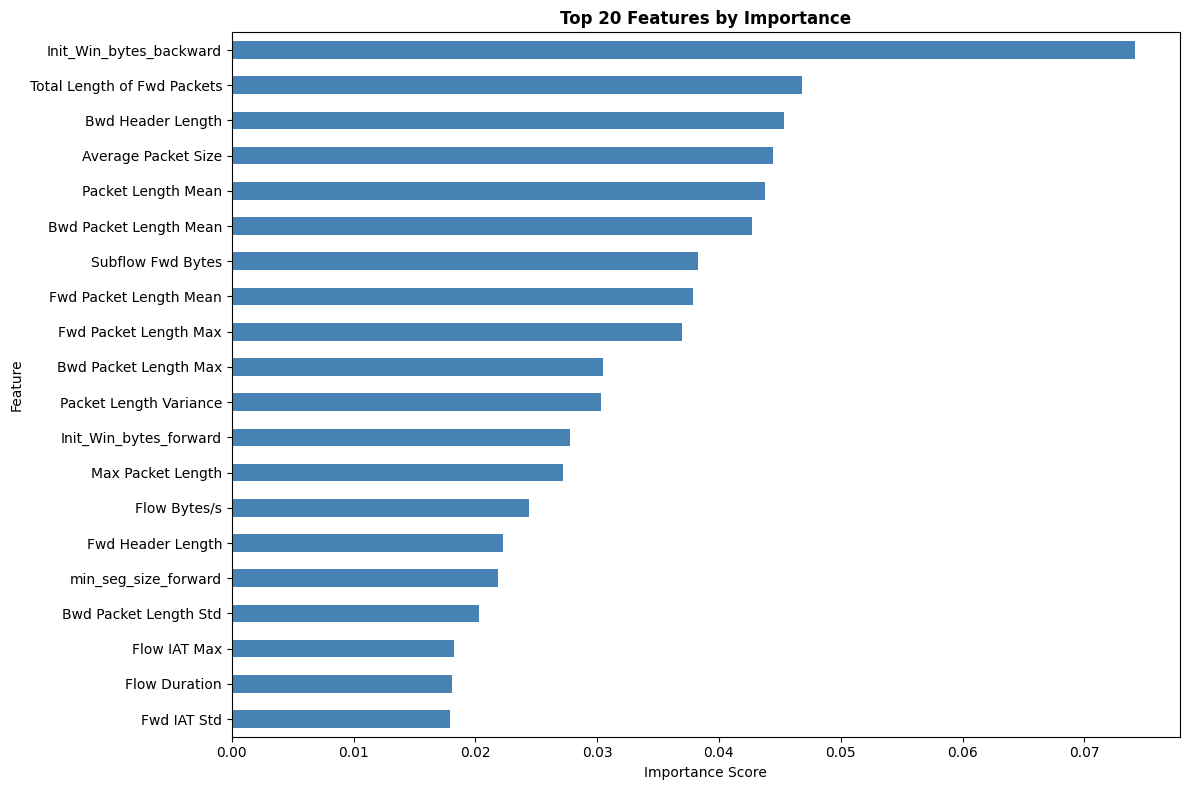

In [10]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print("="*80)
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['Feature']:40s} {row['Importance']:.6f}")
print("="*80)

# Check if any port feature is in top 10
top_10_features = feature_importance.head(10)['Feature'].tolist()
port_in_top_10 = [f for f in top_10_features if 'port' in f.lower()]
if port_in_top_10:
    print(f"\n⚠️  WARNING: Port features in top 10: {port_in_top_10}")
else:
    print(f"\n✓ SUCCESS: No port features in top 10 (overfitting eliminated)")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))
feature_importance.head(20).sort_values('Importance').plot(
    kind='barh', 
    x='Feature', 
    y='Importance', 
    ax=ax, 
    color='steelblue',
    legend=False
)
ax.set_title('Top 20 Features by Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Model Export with Confidence Scores

**Goal:** Save model and feature list for inference; enable confidence score output.

In [14]:
# Ensure model directory exists
os.makedirs('./model', exist_ok=True)

# Save the trained model
model_filename = './model/random_forest_model_v2.pkl'
joblib.dump(rf_model, model_filename)
print(f"Model saved to: {model_filename}")

# Feature list already saved in Step 3
feature_filename = './model/model_columns_v2.joblib'
print(f"Features saved to: {feature_filename}")

# Test loading to verify
loaded_model = joblib.load(model_filename)
loaded_features = joblib.load(feature_filename)
print(f"\nVerification:")
print(f"  Loaded model type: {type(loaded_model).__name__}")
print(f"  Loaded features count: {len(loaded_features)}")
print(f"  Model is ready for inference")

Model saved to: ./model/random_forest_model_v2.pkl
Features saved to: ./model/model_columns_v2.joblib

Verification:
  Loaded model type: RandomForestClassifier
  Loaded features count: 51
  Model is ready for inference


Confidence Score Statistics:
  Min: 0.3800
  Max: 1.0000
  Mean: 0.9984
  Median: 1.0000

Predictions by confidence level:
  High confidence (>0.9): 150524 (99.52%)
  Medium confidence (0.7-0.9): 517 (0.34%)
  Low confidence (<0.7): 205 (0.14%)


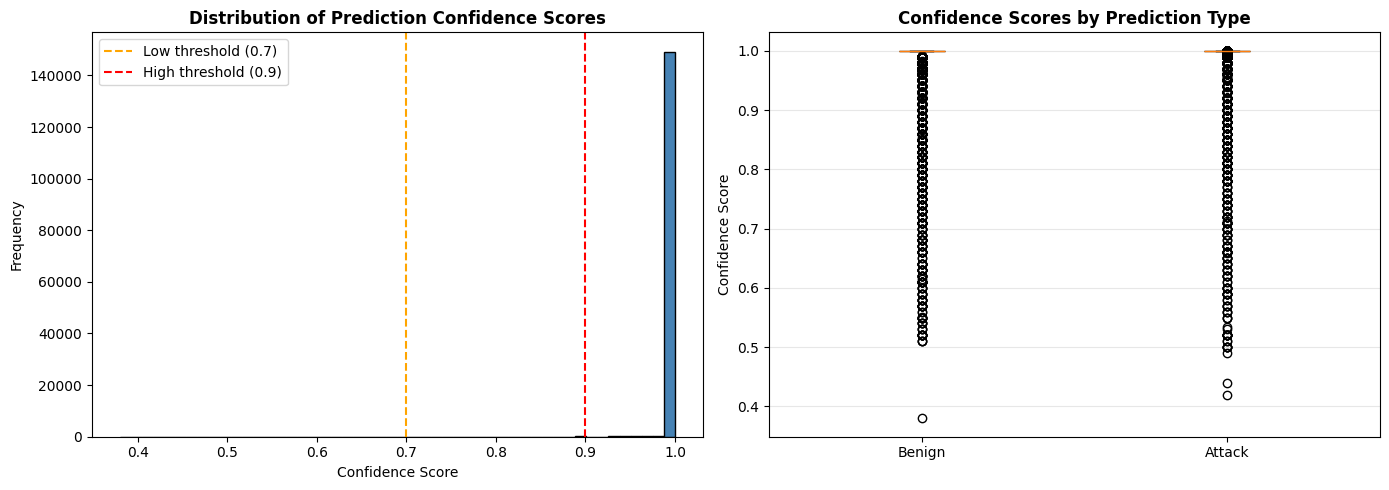

In [15]:
# Analyze confidence scores on test set
confidence_scores = y_pred_proba.max(axis=1)

print("Confidence Score Statistics:")
print(f"  Min: {confidence_scores.min():.4f}")
print(f"  Max: {confidence_scores.max():.4f}")
print(f"  Mean: {confidence_scores.mean():.4f}")
print(f"  Median: {np.median(confidence_scores):.4f}")

print(f"\nPredictions by confidence level:")
print(f"  High confidence (>0.9): {(confidence_scores > 0.9).sum()} ({(confidence_scores > 0.9).sum() / len(confidence_scores) * 100:.2f}%)")
print(f"  Medium confidence (0.7-0.9): {((confidence_scores >= 0.7) & (confidence_scores <= 0.9)).sum()} ({((confidence_scores >= 0.7) & (confidence_scores <= 0.9)).sum() / len(confidence_scores) * 100:.2f}%)")
print(f"  Low confidence (<0.7): {(confidence_scores < 0.7).sum()} ({(confidence_scores < 0.7).sum() / len(confidence_scores) * 100:.2f}%)")

# Visualize confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(confidence_scores, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Prediction Confidence Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0.7, color='orange', linestyle='--', label='Low threshold (0.7)')
axes[0].axvline(x=0.9, color='red', linestyle='--', label='High threshold (0.9)')
axes[0].legend()

# Confidence by prediction (benign vs attack)
benign_mask = y_pred == 'Normal Traffic'
attack_mask = y_pred != 'Normal Traffic'

axes[1].boxplot([confidence_scores[benign_mask], confidence_scores[attack_mask]], 
                labels=['Benign', 'Attack'],
                patch_artist=True)
axes[1].set_title('Confidence Scores by Prediction Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confidence Score')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
print("="*80)
print("MODEL TRAINING SUMMARY - V2")
print("="*80)
print(f"\n📊 DATA:")
print(f"  • Original dataset: 2,520,751 records")
print(f"  • Sampled for training: {len(df):,} records (30%)")
print(f"  • Training set: {len(X_train):,} records")
print(f"  • Test set: {len(X_test):,} records")
print(f"  • Memory footprint reduced by: ~60%")

print(f"\n🎯 FEATURES:")
print(f"  • Original feature count: 52")
print(f"  • Features after port removal: {len(X)}")
print(f"  • Port-related features removed: {len(port_features)}")
print(f"  • ✓ Destination port overfitting ELIMINATED")

print(f"\n🤖 MODEL IMPROVEMENTS:")
print(f"  • Class weighting: ENABLED (balanced)")
print(f"  • Stratified cross-validation: 5-fold F1 = {cv_scores.mean():.4f}")
print(f"  • Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  • Confidence scoring: ENABLED (available via predict_proba)")
print(f"  • High-confidence predictions (>0.9): {(confidence_scores > 0.9).sum() / len(confidence_scores) * 100:.1f}%")

print(f"\n📁 FILES SAVED:")
print(f"  ✓ ./model/random_forest_model_v2.pkl")
print(f"  ✓ ./model/model_columns_v2.joblib")

print(f"\n📋 NEXT STEPS:")
print(f"  1. Update ids_core/model_loader.py to load v2 model")
print(f"  2. Update ids_core/pipeline.py feature extraction for v2 features")
print(f"  3. Run SSH brute-force test to verify attack detection")
print(f"  4. Monitor live traffic for false positives/negatives")
print(f"\n" + "="*80)

MODEL TRAINING SUMMARY - V2

📊 DATA:
  • Original dataset: 2,520,751 records
  • Sampled for training: 756,226 records (30%)
  • Training set: 604,980 records
  • Test set: 151,246 records
  • Memory footprint reduced by: ~60%

🎯 FEATURES:
  • Original feature count: 52
  • Features after port removal: 756226
  • Port-related features removed: 1
  • ✓ Destination port overfitting ELIMINATED

🤖 MODEL IMPROVEMENTS:
  • Class weighting: ENABLED (balanced)
  • Stratified cross-validation: 5-fold F1 = 0.9983
  • Test accuracy: 0.9984
  • Confidence scoring: ENABLED (available via predict_proba)
  • High-confidence predictions (>0.9): 99.5%

📁 FILES SAVED:
  ✓ ./model/random_forest_model_v2.pkl
  ✓ ./model/model_columns_v2.joblib

📋 NEXT STEPS:
  1. Update ids_core/model_loader.py to load v2 model
  2. Update ids_core/pipeline.py feature extraction for v2 features
  3. Run SSH brute-force test to verify attack detection
  4. Monitor live traffic for false positives/negatives



## 10. Model Calibration Check

**Goal:** Verify model is well-calibrated (confidence matches accuracy).


Model Calibration Analysis

Calibration by Confidence Bin:
Confidence Range     True Accuracy   Count     
--------------------------------------------------
0.3 - 0.4        62.50%            1
0.4 - 0.5        78.38%            3
0.5 - 0.6        90.03%            92
0.6 - 0.7        99.94%            120

INTERPRETATION:
✓ WELL-CALIBRATED: True accuracy ≈ Confidence (e.g., 0.95 confidence → 95% correct)
✗ OVERFITTED: True accuracy << Confidence (e.g., 0.99 confidence → 85% correct)
✗ UNDERFITTED: True accuracy >> Confidence (e.g., 0.80 confidence → 95% correct)


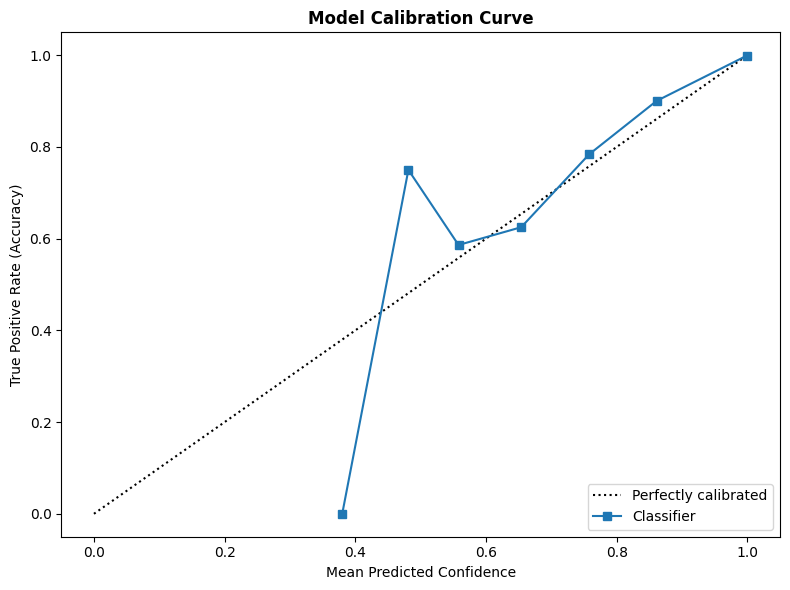


⚠️  If the curve is ABOVE the diagonal (45° line): Model is overconfident (OVERFITTING)
✓ If the curve is CLOSE to the diagonal: Model is well-calibrated (GOOD)


In [17]:
# Calibration check: Does confidence match actual accuracy?
from sklearn.calibration import calibration_curve

print("Model Calibration Analysis")
print("="*80)

# Get probabilities and bin them
prob_true, prob_pred = calibration_curve(
    y_test == y_pred,  # 1 if correct, 0 if wrong
    confidence_scores,
    n_bins=10
)

print(f"\nCalibration by Confidence Bin:")
print(f"{'Confidence Range':20s} {'True Accuracy':15s} {'Count':10s}")
print("-" * 50)

for i in range(len(prob_pred)):
    bin_start = i * 0.1
    bin_end = (i + 1) * 0.1
    count = ((confidence_scores >= bin_start) & (confidence_scores < bin_end)).sum()
    if count > 0:
        print(f"{bin_start:.1f} - {bin_end:.1f}        {prob_true[i]:.2%}            {count:,}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("✓ WELL-CALIBRATED: True accuracy ≈ Confidence (e.g., 0.95 confidence → 95% correct)")
print("✗ OVERFITTED: True accuracy << Confidence (e.g., 0.99 confidence → 85% correct)")
print("✗ UNDERFITTED: True accuracy >> Confidence (e.g., 0.80 confidence → 95% correct)")

# Plot calibration curve
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_test == y_pred,
    confidence_scores,
    n_bins=10,
    ax=ax
)
ax.set_title('Model Calibration Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Predicted Confidence')
ax.set_ylabel('True Positive Rate (Accuracy)')
plt.tight_layout()
plt.show()

print("\n⚠️  If the curve is ABOVE the diagonal (45° line): Model is overconfident (OVERFITTING)")
print("✓ If the curve is CLOSE to the diagonal: Model is well-calibrated (GOOD)")



APPLYING ISOTONIC CALIBRATION

Calibrated Confidence Scores:
  Min: 0.4057
  Max: 0.9999
  Mean: 0.9983
  Median: 0.9999

Calibrated Predictions by confidence level:
  High confidence (>0.9): 150700 (99.64%)
  Medium confidence (0.7-0.9): 358 (0.24%)
  Low confidence (<0.7): 188 (0.12%)

Calibrated Model Accuracy: 0.9984
Original Model Accuracy: 0.9984


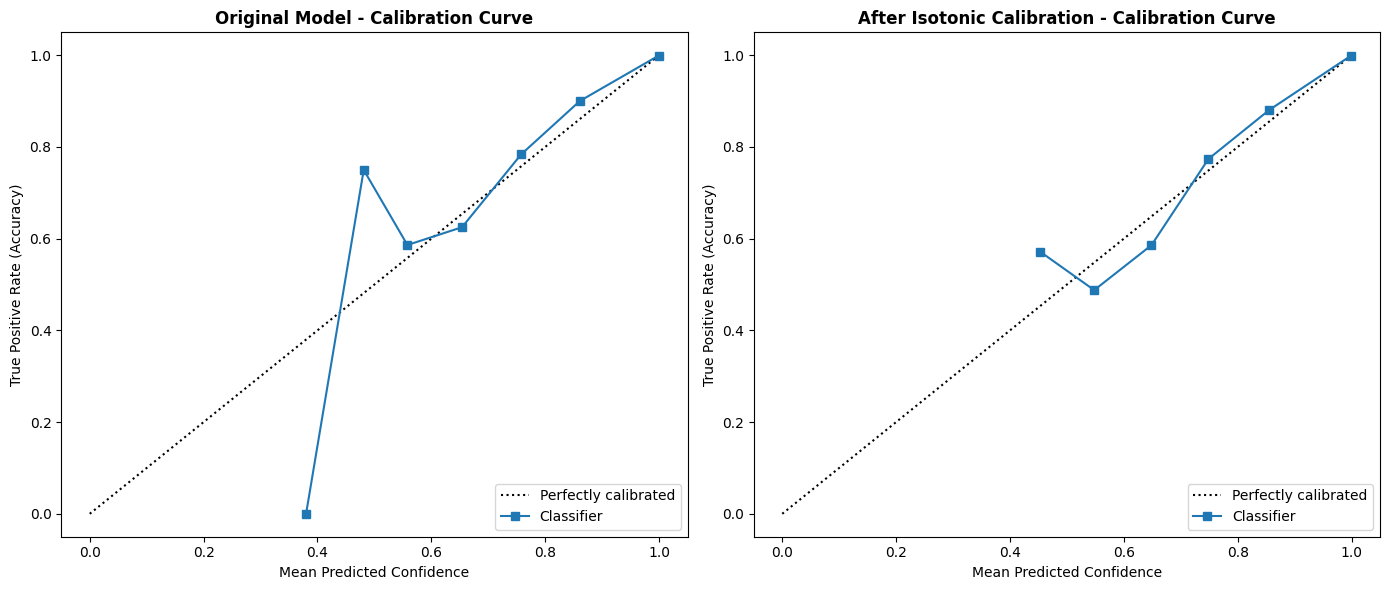


✓ Calibrated model saved to: ./model/random_forest_model_v2_calibrated.pkl
  (Keep original model as backup for comparison)


In [18]:

# Optional: Apply isotonic calibration to fix overconfidence
from sklearn.calibration import CalibratedClassifierCV

print("\n" + "="*80)
print("APPLYING ISOTONIC CALIBRATION")
print("="*80)

# Train calibration on hold-out cross-validation data
calibrated_rf = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    method='isotonic',  # Non-parametric: learns mapping from raw → calibrated probabilities
    cv=5
)

calibrated_rf.fit(X_train, y_train)

# Get calibrated predictions
y_pred_calibrated = calibrated_rf.predict(X_test)
y_pred_proba_calibrated = calibrated_rf.predict_proba(X_test)
confidence_scores_calibrated = y_pred_proba_calibrated.max(axis=1)

print(f"\nCalibrated Confidence Scores:")
print(f"  Min: {confidence_scores_calibrated.min():.4f}")
print(f"  Max: {confidence_scores_calibrated.max():.4f}")
print(f"  Mean: {confidence_scores_calibrated.mean():.4f}")
print(f"  Median: {np.median(confidence_scores_calibrated):.4f}")

print(f"\nCalibrated Predictions by confidence level:")
print(f"  High confidence (>0.9): {(confidence_scores_calibrated > 0.9).sum()} ({(confidence_scores_calibrated > 0.9).sum() / len(confidence_scores_calibrated) * 100:.2f}%)")
print(f"  Medium confidence (0.7-0.9): {((confidence_scores_calibrated >= 0.7) & (confidence_scores_calibrated <= 0.9)).sum()} ({((confidence_scores_calibrated >= 0.7) & (confidence_scores_calibrated <= 0.9)).sum() / len(confidence_scores_calibrated) * 100:.2f}%)")
print(f"  Low confidence (<0.7): {(confidence_scores_calibrated < 0.7).sum()} ({(confidence_scores_calibrated < 0.7).sum() / len(confidence_scores_calibrated) * 100:.2f}%)")

print(f"\nCalibrated Model Accuracy: {accuracy_score(y_test, y_pred_calibrated):.4f}")
print(f"Original Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Compare calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
from sklearn.calibration import CalibrationDisplay
CalibrationDisplay.from_predictions(
    y_test == y_pred,
    confidence_scores,
    n_bins=10,
    ax=axes[0]
)
axes[0].set_title('Original Model - Calibration Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Predicted Confidence')
axes[0].set_ylabel('True Positive Rate (Accuracy)')

# Calibrated
CalibrationDisplay.from_predictions(
    y_test == y_pred_calibrated,
    confidence_scores_calibrated,
    n_bins=10,
    ax=axes[1]
)
axes[1].set_title('After Isotonic Calibration - Calibration Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Confidence')
axes[1].set_ylabel('True Positive Rate (Accuracy)')

plt.tight_layout()
plt.show()

# Save calibrated model
calibrated_model_filename = './model/random_forest_model_v2_calibrated.pkl'
joblib.dump(calibrated_rf, calibrated_model_filename)
print(f"\n✓ Calibrated model saved to: {calibrated_model_filename}")
print("  (Keep original model as backup for comparison)")
